Aim to complete parts of this tutorial on your own *before* the practical session (after the lecture).

Use the practical session to get help for any aspect you do not understand or were unable to complete.

# Dimensionality Reduction 1

Learning objectives
1. Apply PCA to different data sets and interpret the output using the popular python library [sklearn](https://scikit-learn.org/stable/)
2. Learn how to visualise the model output
3. Interpret the results to learn about the data structure and potential outliers
4. Code your own function to perform scaling (centering and auto-scaling) using only the numpy.mean and numpy.std functions and two datasets as input (training, test) - use generative AI to help write the code
5. Investigate the effect of scaling the data on the output

## Import specific packages and functions

In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, SparsePCA, KernelPCA
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler

## Read in the omics datasets using the pandas [read_excel()](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html) function.
For this example we will be using some COVID19 proteomics data.

**It is important that the Data folder is placed in the same location as the folders of each of the notebooks.** Otherwise you need to edit the data path in each notebook. Here it goes back to the parent directory of this Notebook and then into the Data-main folder to load the dataset.

In [12]:
%pwd

'/content'

In [13]:
covid_proteomics = pd.read_excel("../Data/COVID19_proteomics.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '../Data/COVID19_proteomics.xlsx'

In [ ]:
covid_proteomics.head(20)

,COVID19,sample_time,sample_id,"lectin, galactoside-binding, soluble, 9","tumor necrosis factor receptor superfamily, member 10a",agouti related protein homolog (mouse),"tumor necrosis factor receptor superfamily, member 10b","tumor necrosis factor receptor superfamily, member 13B",c-fos induced growth factor (vascular endothelial growth factor D),dickkopf WNT signaling pathway inhibitor 1,...,"EGF-like-domain, multiple 7",REST corepressor 1,carbonic anhydrase XIV,syntaxin 8,"protein kinase, AMP-activated, beta 1 non-catalytic subunit",mitogen-activated protein kinase kinase kinase kinase 5,negative regulator of ubiquitin-like proteins 1,ectonucleoside triphosphate diphosphohydrolase 2,"melanoma antigen family D, 1",G protein-coupled receptor 56
0,0,0,1010823,9.467005,3.150612,4.765860,5.853070,9.776093,8.076783,10.286002,...,5.089420,1.904315,2.354585,3.370510,1.457120,6.393335,1.888595,1.272365,-1.015575,1.774740
1,0,0,1027114,2.414755,1.457353,1.244160,0.712265,2.301213,0.910362,-0.073302,...,5.737120,1.706265,2.174810,2.320480,0.754500,3.058775,0.745930,1.413305,-1.683045,1.542735
2,0,0,1029090,9.581175,3.121713,4.649250,5.796290,9.494383,8.618412,9.356512,...,5.046855,1.923825,2.362200,3.534835,1.649450,5.595935,2.099020,1.539440,-0.599360,1.543860
3,0,0,1049423,9.391395,3.068790,4.669920,5.773255,11.887820,7.702655,9.278815,...,4.665445,1.910215,2.364895,3.594625,1.468635,5.781550,1.864265,1.657420,-0.094040,1.229660
4,0,0,1057525,9.142025,3.198663,5.430080,5.614800,9.746692,8.250982,9.407002,...,5.510625,1.770395,2.533960,3.393515,1.293010,5.925985,1.124380,1.383710,-0.680310,1.763090
5,0,0,1065558,9.520395,3.261270,4.810595,5.796090,9.716400,7.394165,9.578205,...,4.844270,1.815715,2.229780,2.416590,0.494190,4.416565,0.394440,1.336955,-1.091685,1.358405
6,0,0,1066842,9.704675,3.327310,4.735280,7.927645,9.807930,7.085200,9.988565,...,5.578100,1.840535,2.070480,3.841480,1.509670,5.866515,1.869450,1.275495,-0.489305,2.541955
7,0,0,1075315,9.398315,3.133215,4.500165,5.613260,9.180295,8.329575,10.057185,...,5.476575,2.504045,3.081320,3.754045,2.359585,7.841550,2.747405,1.555540,0.038790,1.650520
8,0,0,1097616,10.115740,3.683935,4.306665,5.763435,9.662610,7.859150,9.829915,...,5.615135,1.915235,2.611660,4.715735,2.075320,7.149175,1.929220,1.437280,0.332150,1.697690
9,0,0,1100090,9.711635,3.305100,4.718785,5.954905,9.393805,8.046555,9.877380,...,5.301765,1.962355,2.603330,4.142485,1.839545,5.733170,2.374105,1.158960,-0.173210,3.355640


In [ ]:
# If you are using Google Colab 
# Remove the # comment below and use these instructions instead to download and open the dataset
# !wget https://raw.github.com/ICL-BMB-BiDS/Data/main/COVID19_proteomics.xlsx
# covid_proteomics = pd.read_excel("./COVID19_proteomics.xlsx")

We can see the data has three metadata colums: COVID19 (disease status), sample_time (when the blood draw was taken), and sample_id.

## Principal Component Analysis (PCA)
Read more about PCA in the sklearn [documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)

Use the sklearn [PCA()](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA) function to initialise a PCA object. What is the maximum number of components you can have for a PCA model?

In [ ]:
pca_res = PCA(n_components=4)
# run PCA with 4 components

Apply the `fit_transform()` function to the PCA object to perform PCA dimensionality reduction on the data and project the data to the latent space. Note: we must exclude any sample metadata columns beforehand (remember Python starts counting at 0). 

In [ ]:
# covid_proteomics.iloc[:, 3:] dataframe without the first 3 metadata columns
#fit_transform only the value columns of the dataframe, not the metadata columns
pca_covid = pca_res.fit_transform(covid_proteomics.iloc[:, 3:])

By appling `fit_transform` we project the proteomics data into the latent subspace captured by PCA. The results, also known as **PCA scores** are stored in the results of `fit_transform`, in our case the variable `pca_covid`. Let's look at the PCA results:

In [ ]:
pca_covid

array([[ -6.24856647,  -7.36857879,   4.40201038,   1.36812633],
       [-40.08553647, -13.39870705, -27.83657184,   4.86126474],
       [-11.13448435,  -4.11273316,   3.34527148,   1.06040948],
       ...,
       [  4.8867819 ,  -6.00553464,  -0.48956669,  -3.05076358],
       [ 19.00325325,   7.85874695,   1.33715064,  -3.38606691],
       [ 16.43126614,   6.41402614,   3.59677687,  -4.58113985]],
      shape=(382, 4))

In [ ]:
print(pca_covid.shape)
print(type(pca_covid))

(382, 4)
<class 'numpy.ndarray'>


The results are returned as a numpy array, in this case of size 382 rows (number of samples) by 4 columns (number of components we selected)

We can also obtain the PCA components, **also known as eigenvectors**, which represent the influence of each variable (in this case each protein) within each principal component. We do so using the `components_` attribute of the PCA results. There are 4 rows (components) and 450 columns (proteins).

In [ ]:
print(pca_res.components_)
print()
print(pca_res.components_.shape)

[[ 0.03303302  0.02589285  0.03162731 ...  0.01198025  0.06189392
   0.01847887]
 [ 0.06091291  0.07727395  0.03942287 ...  0.01402203  0.01067513
   0.05961235]
 [ 0.01455189  0.02557657  0.08153593 ...  0.03562647 -0.01231284
   0.06284832]
 [-0.00419266 -0.02049046 -0.00140445 ...  0.06122292  0.0182962
  -0.02878856]]

(4, 450)


## PCA visualisation

Visualise two sets of PCA scores against each other with a PCA biplot.

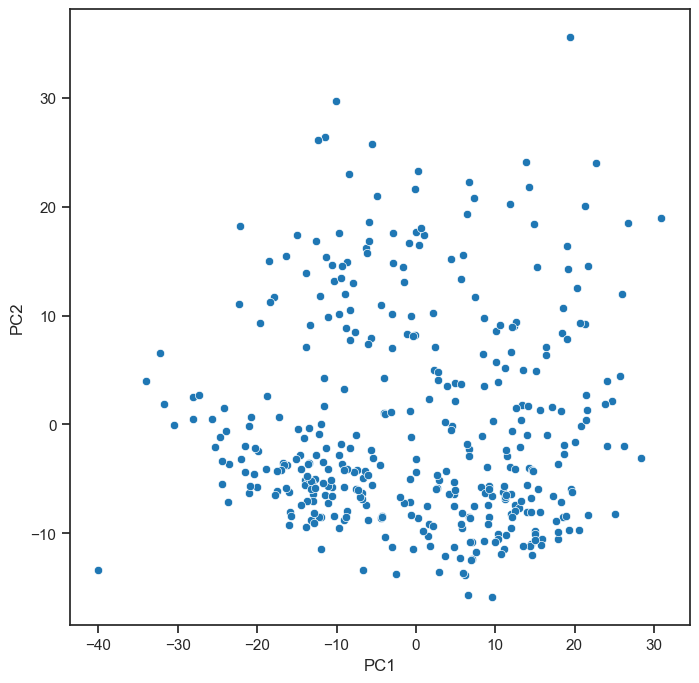

In [ ]:
# set plotting parameters
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

# plot a scatterplot using seaborn
# the x axis will contain the first column of the pca scores x=pca_covid[:, 0]
p = sns.scatterplot(x=pca_covid[:, 0], y=pca_covid[:, 1])

p.set_xlabel("PC1")
p.set_ylabel("PC2")

plt.show()

Colour the scatterpoints on the scatterplot by some metadata - here we will use COVID19 status

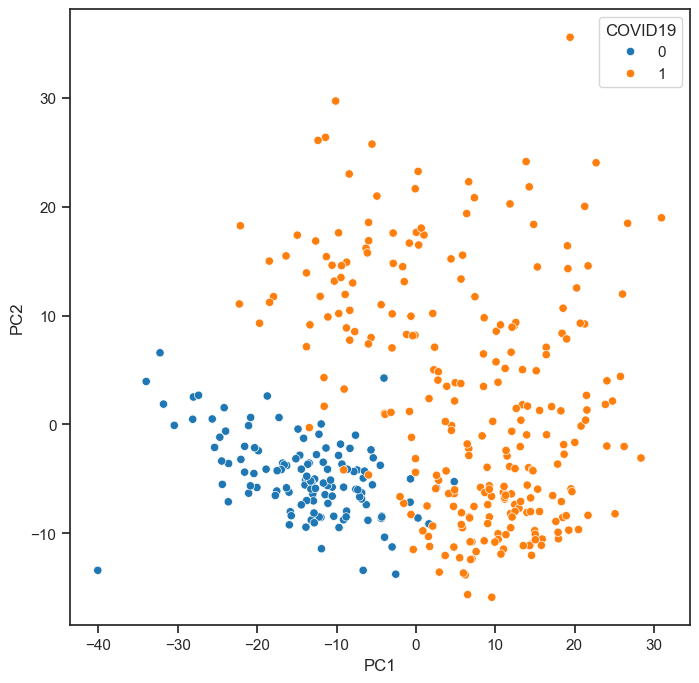

In [ ]:
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=pca_covid[:, 0], y=pca_covid[:, 1], hue=covid_proteomics["COVID19"])

p.set_xlabel("PC1")
p.set_ylabel("PC2")

plt.show()

Visualise multiple components against each other. Here we make use of the seaborn [pairplot()](https://seaborn.pydata.org/generated/seaborn.pairplot.html) function to do so

In [ ]:
# make a dataframe to store the PCA scores for each component alongside the sample metadata
pca_df = pd.DataFrame(pca_covid, columns=["PC"+str(i) for i in range(1, pca_covid.shape[1]+1)])
pca_df["COVID_status"] = covid_proteomics["COVID19"]

pca_df

,PC1,PC2,PC3,PC4,COVID_status
0,-6.248566,-7.368579,4.402010,1.368126,0
1,-40.085536,-13.398707,-27.836572,4.861265,0
2,-11.134484,-4.112733,3.345271,1.060409,0
3,-13.911648,-5.123886,1.252117,2.484675,0
4,-12.754993,-5.008780,0.698957,-1.045126,0
...,...,...,...,...,...
377,3.895496,3.509694,-7.399634,-3.246642,1
378,2.500047,-5.893374,-4.688830,-3.133457,1
379,4.886782,-6.005535,-0.489567,-3.050764,1
380,19.003253,7.858747,1.337151,-3.386067,1


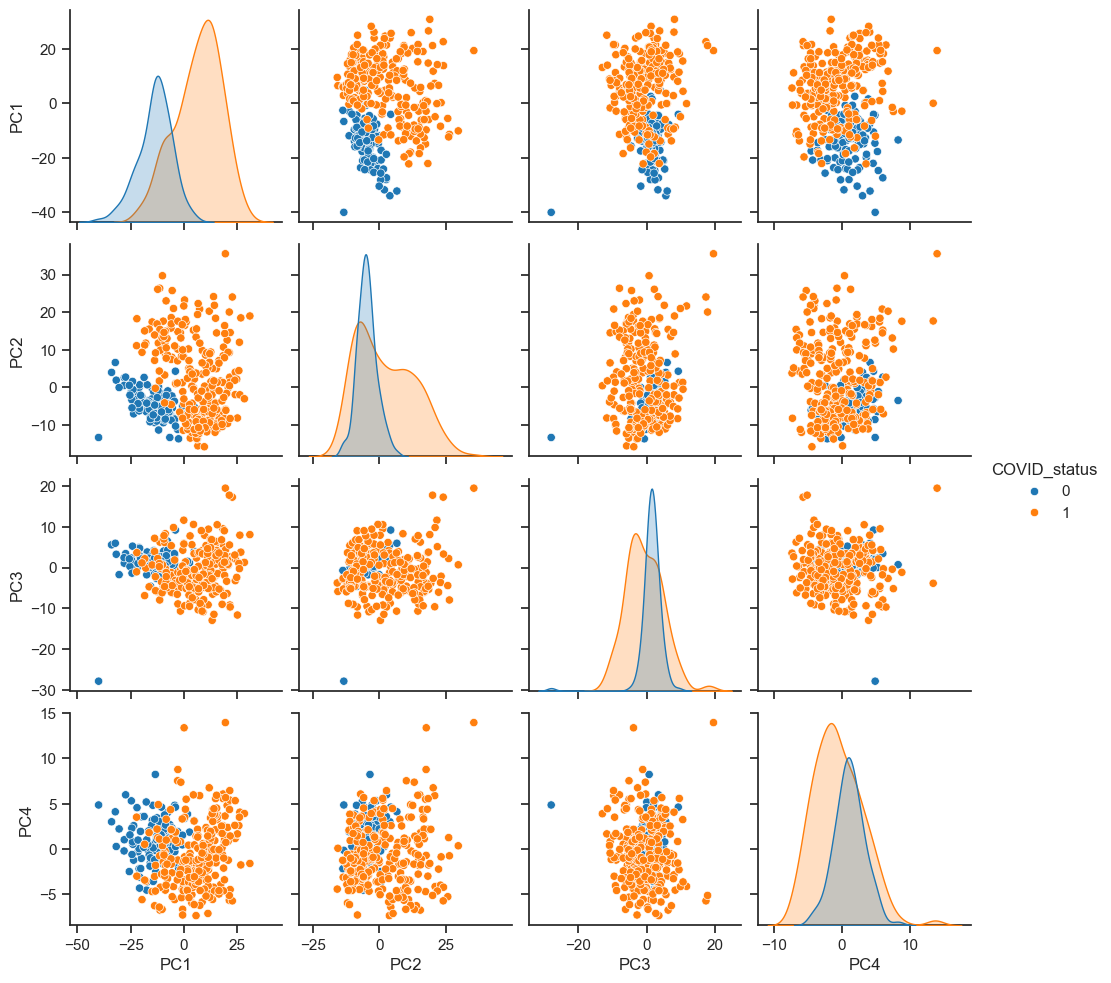

In [ ]:
sns.pairplot(data=pca_df, hue="COVID_status")

plt.show()

### Let's plot the first two components and add the variance explained to the axes

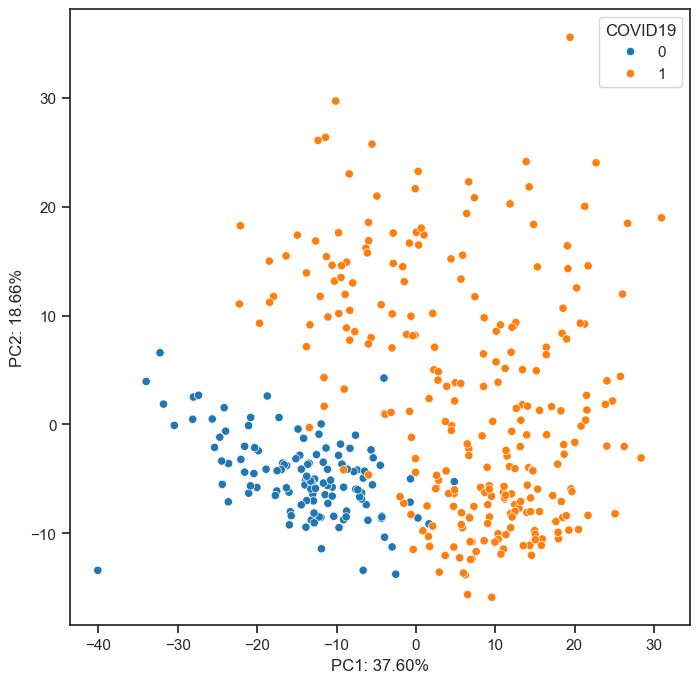

In [ ]:
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=pca_covid[:, 0], y=pca_covid[:, 1], hue=covid_proteomics["COVID19"])

# proportions of variance explained by axes
pvars = pca_res.explained_variance_ratio_[:2] * 100

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

plt.show()

Scree plots show the percentage of the variance in the data explained by each principal component (eigenvalues)

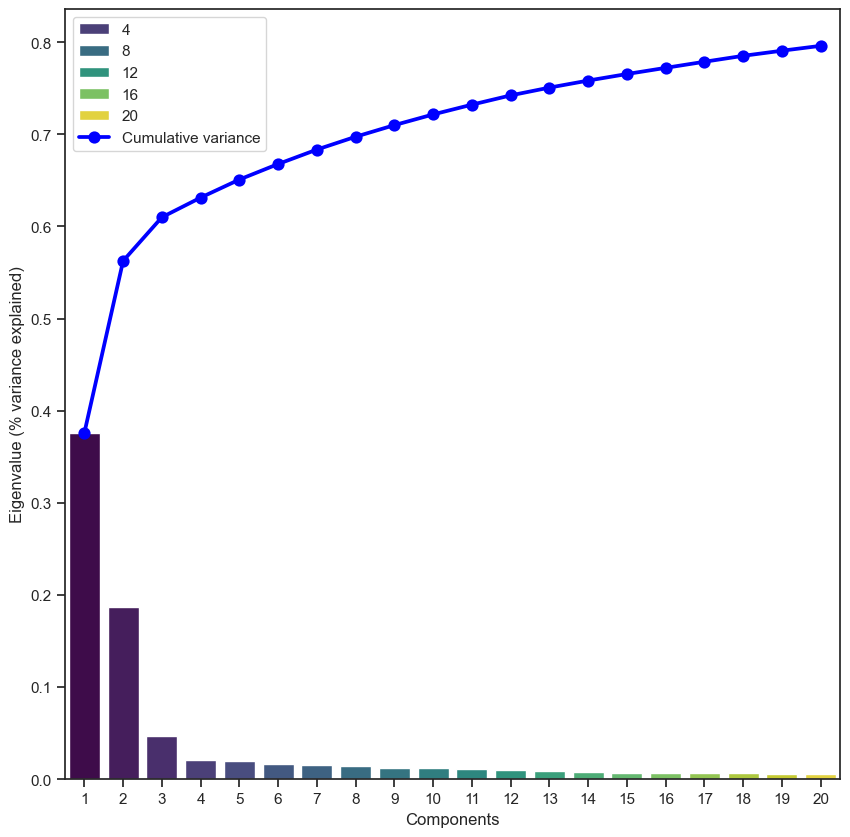

In [ ]:
# Scree plot

# perform PCA with 20 components
pca_covid = PCA(n_components=20)
pca_covid.fit(covid_proteomics.iloc[:, 3:])

# use the attribute .explained_variance_ratio_ to get the eigenvalues
variance_per_component = pca_covid.explained_variance_ratio_

# sum the eigenvalues to get the cumulative variance explained for each component
cumulative_variance = np.cumsum(variance_per_component)
components = list(range(1, 21))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.barplot(x=components, y=variance_per_component, palette="viridis", ax=ax, hue=components)

# show the cumulative variance with a blue line
sns.pointplot(x=components, y=cumulative_variance, ax=ax, color="blue", label="Cumulative variance")

plt.xlabel("Components")
plt.ylabel("Eigenvalue (% variance explained)")
plt.show()

How many components would be required to explain 75% of the variance in the dataset?

### Interpretation of PCA results

Looking at the PCA scoreplot and the PCA pairplot, which PCA component(s) show the most clear separation between COVID19 and non-COVID samples?

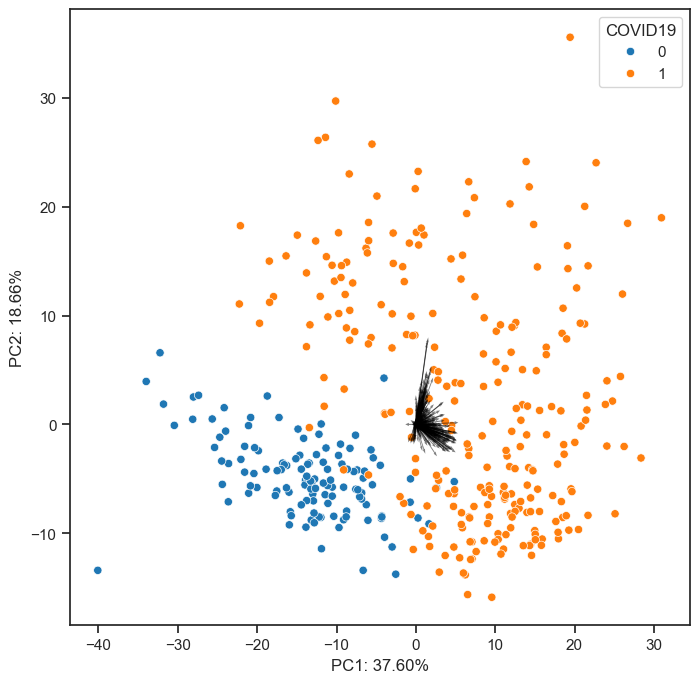

In [ ]:
# extracting the scores and loadings (transposing the latter in the process) of the first 2 components (note: this can be different in other datasets)
scores = pca_covid.transform(covid_proteomics.iloc[:, 3:])
loadings = pca_covid.components_[:2].T
features = list(covid_proteomics.columns[3:])

loadingVector = loadings * np.abs(scores[:, :2]).max(axis=0)

sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=covid_proteomics["COVID19"])

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

# features as arrows
for i, arrow in enumerate(loadingVector):
    plt.arrow(0, 0, *arrow, color='k', alpha=0.5, width=0.1, ec='none', length_includes_head=True)
    #plt.text(*(arrow * 1.05), features[i], ha='center', va='center') # this is commented, see what happens when you uncomment

Clearly we have too many variables to visualise in a biplot (hence we have switched off labelling them), let's visualise the most important features in a loading plot instead. (You could only visualise the top few variables above, but how do you know how many to select?)

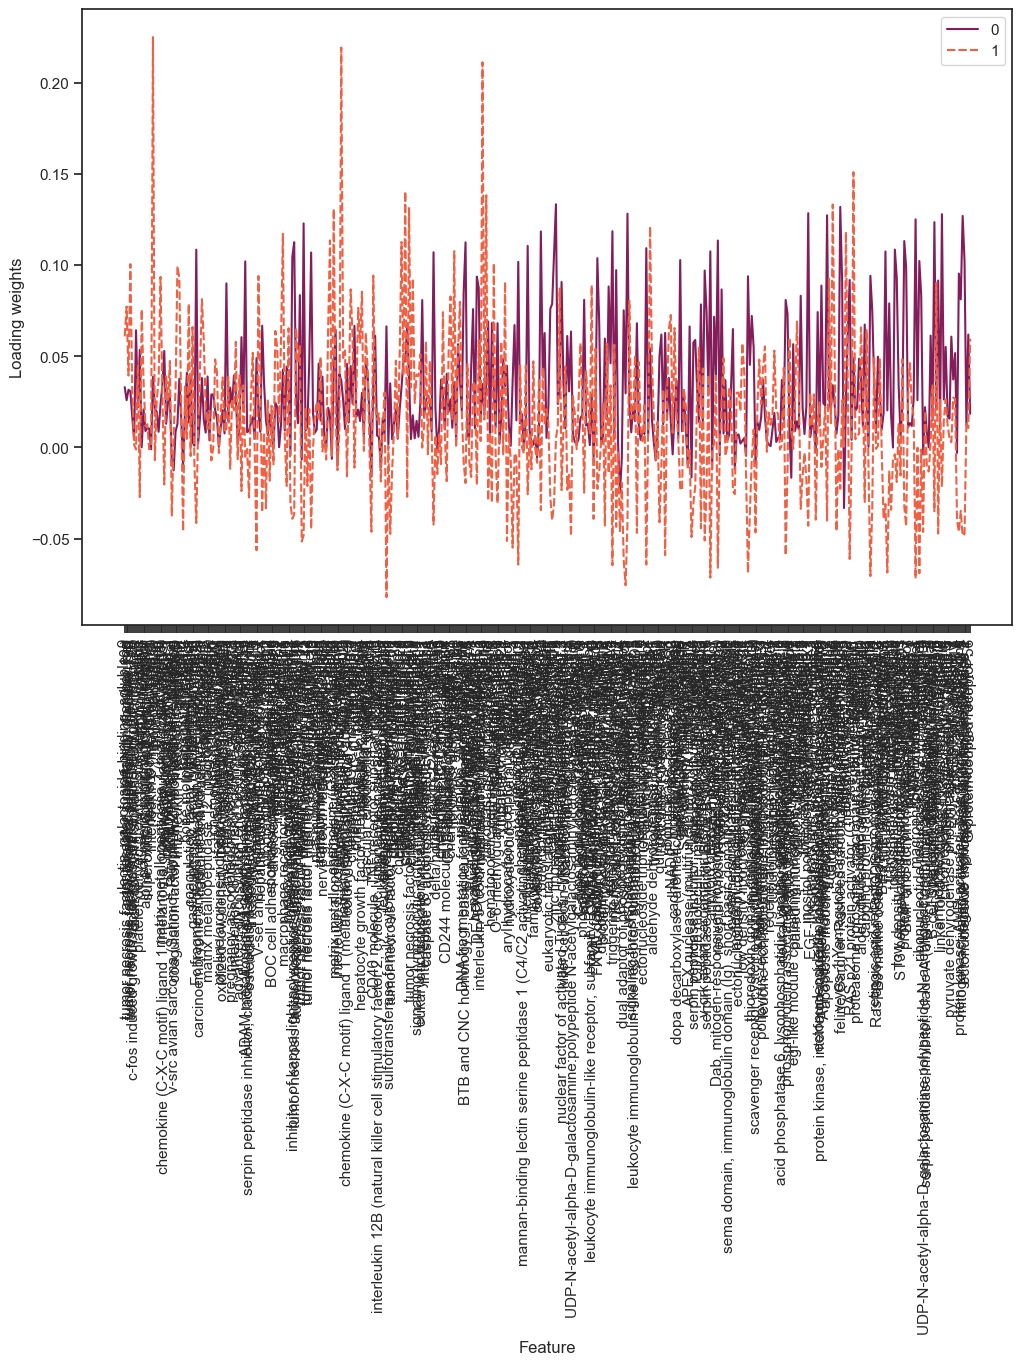

In [ ]:
plt.figure(figsize=(12, 8))

lp = sns.lineplot(data=loadings, palette="rocket")

lp.set_xlabel("Feature")
lp.set_ylabel("Loading weights")
lp.set_xticks(range(len(features)), labels=features, rotation=90)

plt.show()

In this example we might want to select some features that are positive for component 1 and negative for component 2 and those that are negative for component 1 and positive for component 2. As these vectors are in the rough direction of the class separation, be aware that supervised methods (BIDS 7-10) aim to do this as they find the best way to use the features to predict the classes. There can be other reasons to inspect this in an unsupervised analysis such as possible features that are outliers or those that cause groupings that are unrelated to any class.

In [ ]:
loading_vector = loadings[:,0]*loadings[:,1]
n = 20
ind = loading_vector.argsort()[:n]
features = np.array(features)
top_features = features[ind]
top_features

array(['SMAD family member 1', 'annexin A11', 'plexin A4',
       'Dab, mitogen-responsive phosphoprotein, homolog 2 (Drosophila)',
       'vasohibin 1', 'GRB2-related adaptor protein 2',
       'Wiskott-Aldrich syndrome', 'neurofibromin 2 (merlin)',
       'carbonic anhydrase XIII',
       'mitogen-activated protein kinase kinase kinase kinase 5',
       'axin 1', 'parvalbumin',
       'inositol polyphosphate phosphatase-like 1',
       'chemokine (C-X-C motif) ligand 5', 'SH2B adaptor protein 3',
       'apoptosis-inducing factor, mitochondrion-associated, 1',
       'v-crk avian sarcoma virus CT10 oncogene homolog-like',
       'negative regulator of ubiquitin-like proteins 1',
       'STAM binding protein',
       'diablo, IAP-binding mitochondrial protein'], dtype='<U105')

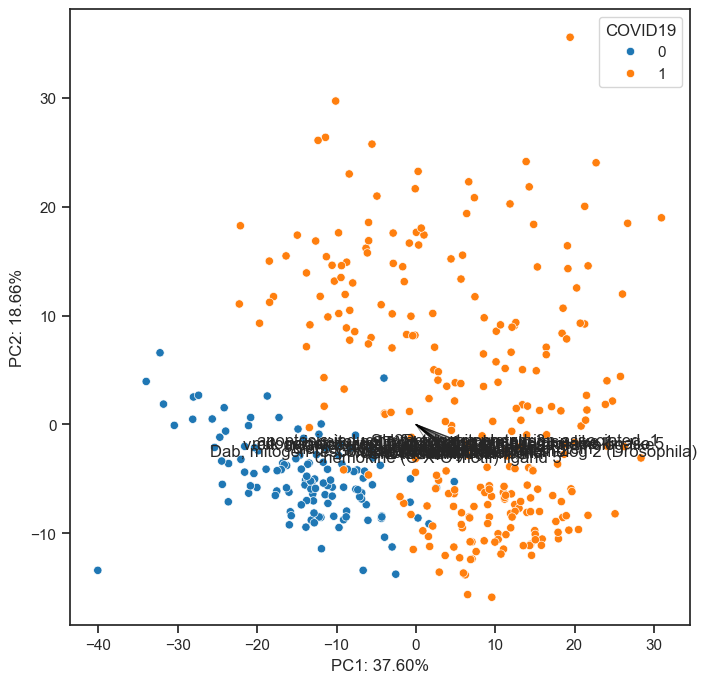

In [ ]:
loadingVector_n = loadingVector[ind,:]

sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=covid_proteomics["COVID19"])

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

# features as arrows
for i, arrow in enumerate(loadingVector_n):
    plt.arrow(0, 0, *arrow, color='k', alpha=0.5, width=0.1, ec='none', length_includes_head=True)
    plt.text(*(arrow * 1.05), top_features[i], ha='center', va='center')

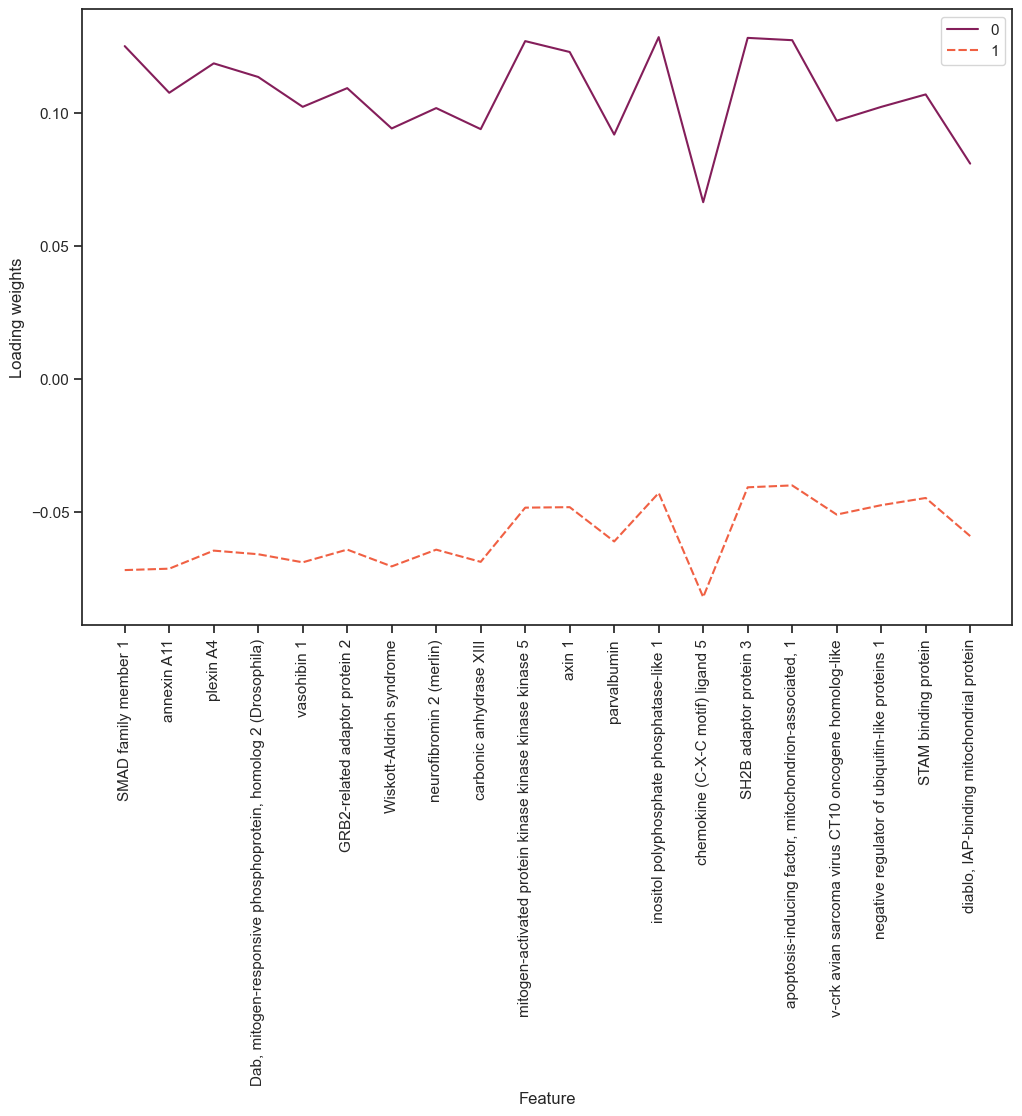

In [ ]:
plt.figure(figsize=(12, 8))

lp = sns.lineplot(data=loadings[ind,:], palette="rocket")

lp.set_xlabel("Feature")
lp.set_ylabel("Loading weights")
lp.set_xticks(range(len(top_features)), labels=top_features, rotation=90)

plt.show()

### Identifying outliers
Samples can be labelled in order to identify those that are outlying.

In [ ]:
plt.figure(figsize=(8,8))
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=covid_proteomics["COVID19"])

# for loop to add labels to each x, y pair along with the corresponding sample ID
for i in range(scores.shape[0]):
    plt.text(x=scores[:, 0][i]+0.3, y=scores[:, 1][i]+0.3, s=covid_proteomics["sample_id"][i], 
          fontdict=dict(color='black',size=8))

plt.tight_layout()
plt.show()

NameError: name 'scores' is not defined

<Figure size 800x800 with 0 Axes>

Are the any obvious outliers in this dataset as seen from this PCA biplot?

## Scaling


The standard score of a sample $x$ is defined as:


$$z = \frac{(x-\mu)}{\sigma}$$

Where:
- $\mu$ is the feature mean
- $\sigma$ is the feature standard deviation



Code a function to scale the data such that each feature has a:
- Mean of 0 
- Standard deviation of 1

Use only the numpy [mean()](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) and numpy [std()](https://numpy.org/doc/stable/reference/generated/numpy.std.html) functions

You can check your answer by comparing it to the result achieved using the sklearn [StandardScaler()](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#:~:text=Standardize%20features%20by%20removing%20the%20mean%20and%20scaling%20to%20unit%20variance.&text=where%20u%20is%20the%20mean,or%20one%20if%20with_std%3DFalse%20.) function

Use a generative AI ([ChatGPT](https://chat.openai.com), [Code-LLaMa](https://poe.com/Code-Llama-34b), etc) of your choice and prompt it step by step to obtain the code. Ensure you only allow it to use numpy functions.

In [ ]:
def my_scaler(data):
    
    # get mean of each column
    mean_col = data.mean(axis=0)

    # subtract the column mean from each value in the column
    mean_centered_data = data - mean_col

    # check the mean of each column is now 0
    #np.allclose Returns True if two arrays are element-wise equal within a tolerance.
    #atol is the maximum allowed difference between the elements of the two arrays for them to be considered equal.
    #rtol is the maximum allowed relative difference between the elements of the two arrays for them to be considered equal.
    #keep the default values 
    print(np.allclose(mean_centered_data.mean(axis=0), 0))

    # get the standard deviations of each column
    std_col= data.std(axis=0)
    # divide the mean centered data by the standard deviation to scale by unit variance
    scaled_data = mean_centered_data / std_col
    
    return scaled_data


In [ ]:
# apply the scaler function to the data
covid_proteomics_scaled = my_scaler(covid_proteomics.iloc[:, 3:])

True


Perform PCA using the scaled data: how many components will you calculate?

In [ ]:
pca_covid_scaled = PCA(n_components=2)
# fit the model using the .fit function
pca_covid_scaled.fit(covid_proteomics_scaled)
# apply the model with .transform to get the scores
scores_scaled = pca_covid_scaled.transform(covid_proteomics_scaled) # can you explain why we do not use iloc here as we did before a few cells above when we extracted the scores by using .transform?

How does scaling affect the PCA? visualise the output

Text(0.5, 1.0, 'Standard scaling')

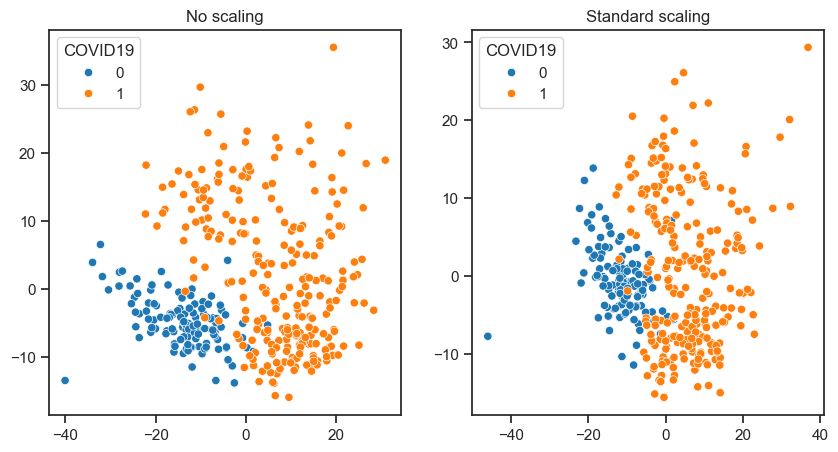

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=covid_proteomics["COVID19"], ax=ax1)
ax1.set_title("No scaling")

sns.scatterplot(x=scores_scaled[:, 0], y=scores_scaled[:, 1], hue=covid_proteomics["COVID19"], ax=ax2)
ax2.set_title("Standard scaling")

sklearn also has a number of inbuilt functions for scaling. Look into the following functions and apply them on the dataset:
- [sklearn.StandardScaler()](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#:~:text=Standardize%20features%20by%20removing%20the%20mean%20and%20scaling%20to%20unit%20variance.&text=where%20u%20is%20the%20mean,or%20one%20if%20with_std%3DFalse%20.)
- [sklearn.RobustScaler()](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html?highlight=robust%20scaler#sklearn.preprocessing.RobustScaler)
- [sklearn.PowerTransformer()](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html?highlight=power%20transformer#sklearn.preprocessing.PowerTransformer)

Let's begin with appling the PowerTransformer():

In [ ]:
# initialise PowerTransformer object
pt = PowerTransformer()

# Apply the power transformation to the data
# note here we can use both fit and transform in a single step using .fit_transform so we only need one line instead of 2 above
covid_proteomics_power_transform = pt.fit_transform(covid_proteomics.iloc[:, 3:])

# Apply PCA to the power transformed data
pca_covid_power_transform = PCA(n_components=2)
pca_covid_power_transform.fit_transform(covid_proteomics_power_transform)
scores_power_transform = pca_covid_power_transform.transform(covid_proteomics_power_transform)

Complete the following code for the Standard Scaler and Robust Scaler:

In [ ]:
# Standard scaler: subtract mean and scale to unit variance
ss = StandardScaler()

# fit the scaler on the feature columns and transform them
covid_proteomics_standard_scaled = ss.fit_transform(covid_proteomics.iloc[:, 3:])

# perform PCA on the standard scaled data, keeping 2 components
pca_covid_standard_scaled = PCA(n_components=2)
scores_standard_scaled = pca_covid_standard_scaled.fit_transform(covid_proteomics_standard_scaled)

# Robust scaler: scale using median and interquartile range, which is less sensitive to outliers
rs = RobustScaler()

# fit the robust scaler on the feature columns and transform them
covid_proteomics_robust_scaled = rs.fit_transform(covid_proteomics.iloc[:, 3:])

# perform PCA on the robust scaled data, keeping 2 components
pca_covid_robust_scaled = PCA(n_components=2)
scores_robust_scaled = pca_covid_robust_scaled.fit_transform(covid_proteomics_robust_scaled)

Visualise the results of the scaling using PCA biplots

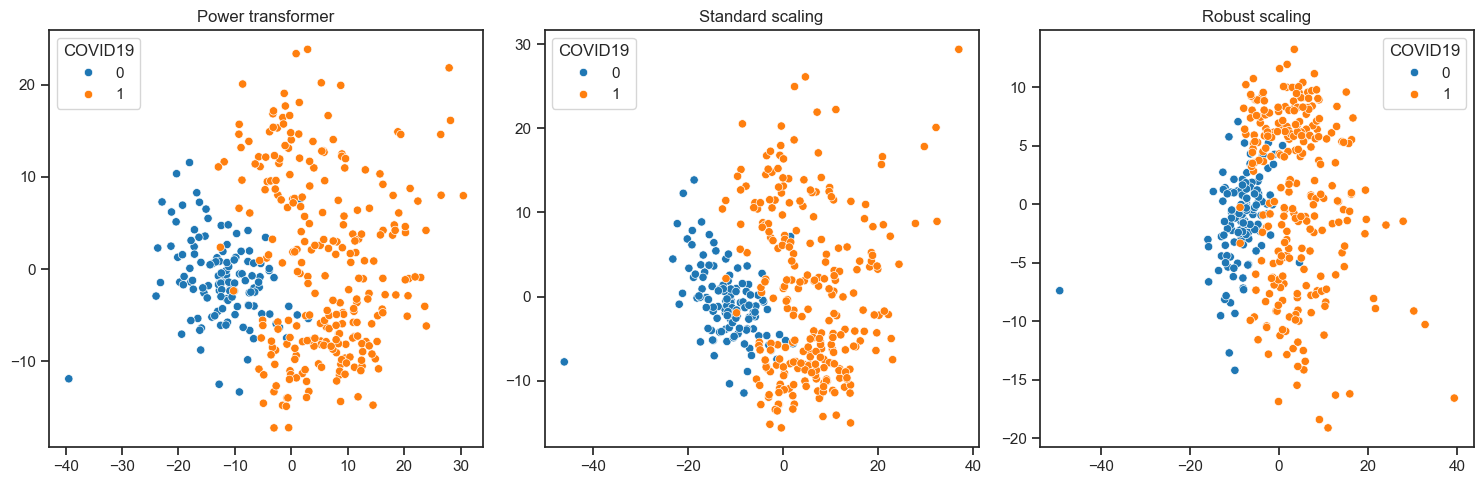

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x=scores_power_transform[:, 0], y=scores_power_transform[:, 1], hue=covid_proteomics["COVID19"], ax=ax1)
ax1.set_title("Power transformer")

sns.scatterplot(x=scores_standard_scaled[:, 0], y=scores_standard_scaled[:, 1], hue=covid_proteomics["COVID19"], ax=ax2)
ax2.set_title("Standard scaling")

sns.scatterplot(x=scores_robust_scaled[:, 0], y=scores_robust_scaled[:, 1], hue=covid_proteomics["COVID19"], ax=ax3)
ax3.set_title("Robust scaling")

plt.tight_layout()
plt.show()

# Outlier detection on scaled data

Now use a generative AI to create the code for calculating Hotelling's T<sup>2</sup> statistic and visualise the outliers (if any) using the [pairplot()](https://seaborn.pydata.org/generated/seaborn.pairplot.html) function as before.

Example prompt:

_Given these packages:_ <br>
_import pandas as pd_ <br>
_import numpy as np_ <br>
_import matplotlib.pyplot as plt_ <br>
_import seaborn as sns_ <br>
_from sklearn.decomposition import PCA, SparsePCA, KernelPCA_ <br>
_from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler_ <br>
_Can you write the code to calculate the Hotelling's T2 statistic to find outliers based on the model below:_ <br>
_pca_covid = PCA(n_components=7).fit_transform(covid_proteomics_robust_scaled)_ <br>
_Then visualise any outliers in a pair plot_

Hotelling's T2 threshold (95%): 14.067140449340169
Number of outliers: 25


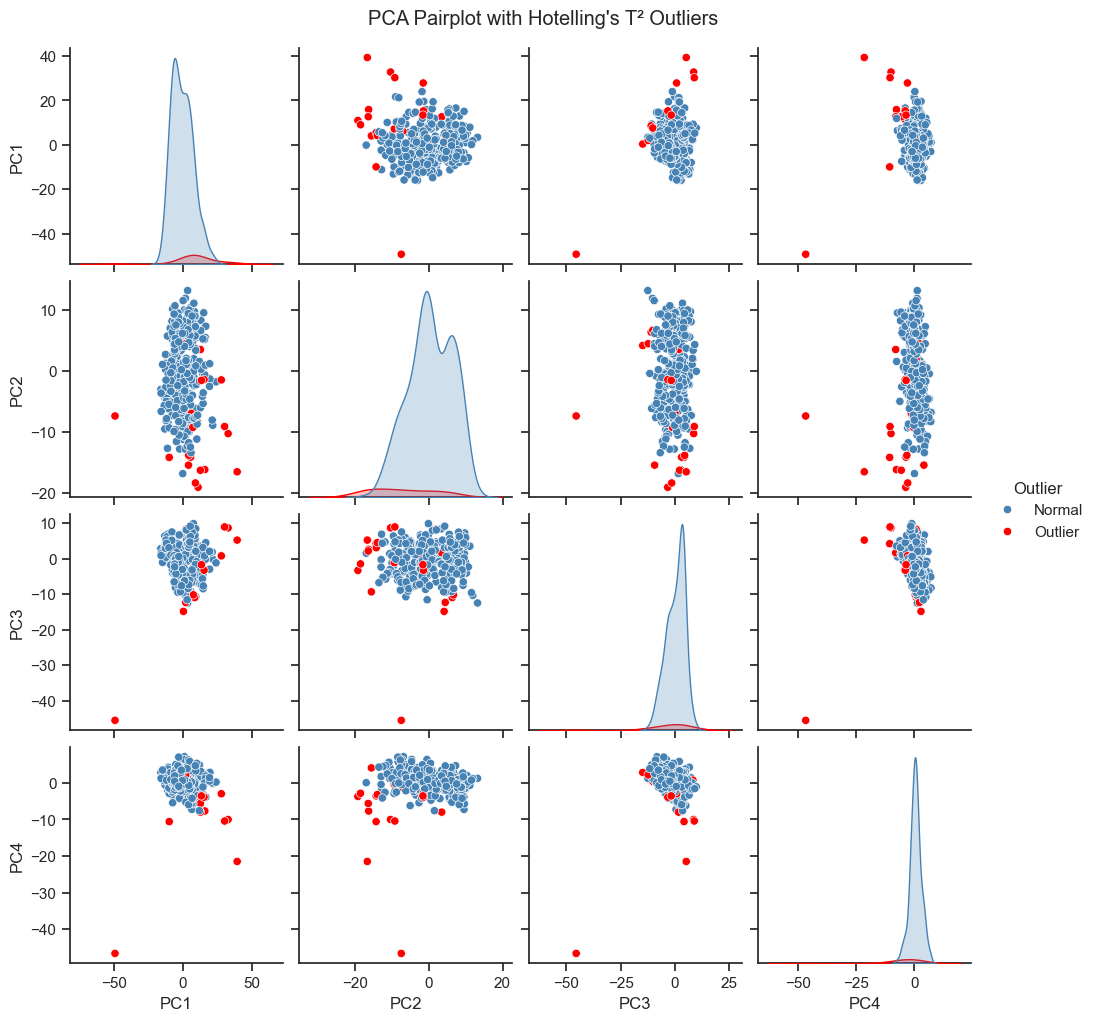

In [ ]:
from scipy.stats import chi2

# ---------------------------------------------------------
# 1. Fit PCA model (7 components)
# ---------------------------------------------------------
pca = PCA(n_components=7)
scores = pca.fit_transform(covid_proteomics_robust_scaled)

# Eigenvalues (variance explained by each PC)
eigenvalues = pca.explained_variance_

# ---------------------------------------------------------
# 2. Hotelling's T² statistic (NumPy only)
#    T²_i = Σ_j ( t_ij² / λ_j )
# ---------------------------------------------------------
t2_stat = np.sum((scores[:, :7] ** 2) / eigenvalues[:7], axis=1)

# ---------------------------------------------------------
# 3. 95% threshold using scipy chi-square distribution
# ---------------------------------------------------------
t2_threshold = chi2.ppf(0.95, df=7)

# Outlier flag
outlier_flag = t2_stat > t2_threshold

# ---------------------------------------------------------
# 4. Build DataFrame for visualization
# ---------------------------------------------------------
pca_df_t2 = pd.DataFrame(
    scores[:, :4],
    columns=[f"PC{i}" for i in range(1, 5)]
)

pca_df_t2["T2"] = t2_stat
pca_df_t2["Outlier"] = np.where(outlier_flag, "Outlier", "Normal")
pca_df_t2["COVID_status"] = covid_proteomics["COVID19"]

print("Hotelling's T2 threshold (95%):", t2_threshold)
print("Number of outliers:", outlier_flag.sum())

# ---------------------------------------------------------
# 5. Pairplot visualization
# ---------------------------------------------------------
sns.pairplot(
    data=pca_df_t2,
    vars=["PC1", "PC2", "PC3", "PC4"],
    hue="Outlier",
    palette={"Normal": "steelblue", "Outlier": "red"},
    diag_kind="kde"
)

plt.suptitle("PCA Pairplot with Hotelling's T² Outliers", y=1.02)
plt.show()


If the above is correct, now see if this can be rewritten in a function you can reuse later on:

Example prompt: _Can you rewrite this as a function with the pca_df and percentile (default as 95) as inputs and outliers as output?_

Sometimes generative AI will get it right the first time, but other times it helps to break it down in parts first before continuing with other steps (visualising, write as function, etc). Or to look at the error you might get, you can copy the error and see if it can solve it or try to do this yourself first. Note that the prompt specifically said to use certain packages, but it may give another option (ask it if it can stick to the packages asked).

In [ ]:
# Add the function here, rewrite it in your preferred style



In [ ]:
# visualise it and compare that it produced the same output as above when it was not a function



## Your turn
Select another dataset from the `Data` folder and import it using the pandas `read_excel()` function as above. Scale the data, and then apply PCA (standard, sparse, or kernel) and visualise the results. Reuse the codes above for a new dataset, copy and paste them below. Reusing existing code (and sometimes slightly adapting it) is common practice, and you will do this as well for the final assignment where you will reuse the materials from the tutorials for the assignment.

What can you interpret from the PCA results? Are there any outliers?

In [ ]:
# Import datasets...



In [ ]:
# Perform scaling...



In [ ]:
# Perform PCA...



In [ ]:
# Visualise PCA results and detect outliers...



# Optional materials

## PCA extensions: sparse PCA and kernel PCA

### Sparse PCA

Sparse PCA is performed using the [SparsePCA()](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html) function. The level of sparsity (the proportion of input variables contributing to the principal components) is controllable by the coefficient of the L1 penalty, given by the parameter `alpha`.

Some algorithms make use of a random process, e.g. to initialise weights it select initial starting points from a random number generator. This means that each time you use the algorithm, the answer might be slightly (sometimes this is unnoticeable) different. Also, this may mean the output you get is different from your neighbour.

How do you get the same answer each time (as long as you do not change any other parameters)? You can set the random state to a specific number.

Random number generators use the computer time and other factors to start at a random place in a huge sequence of random numbers. By setting the ```random_state``` property of an algorithm you will ensure it will start at a standard place. You can pick any positive integer for this. If you look at the documentation of [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA) and [SparsePCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html#sklearn.decomposition.SparsePCA) you will see both of these methods have this argument as input, with a default value, however using other default parameters PCA will give the same output whereas the output from SparsePCA might change.

In [ ]:
# enter your CID here, or date of birth, or another number of your choosing to use as random state
# remember to check the documentation of each algorithm if setting the random_state is needed
CID = 0 # do not add the leading 0

In [ ]:
sparse_pca = SparsePCA(n_components=2, alpha=1, random_state=CID)
sparse_pca_covid = sparse_pca.fit_transform(covid_proteomics.iloc[:, 3:])

Look at the mean number of 0 values across the components (sparsity level). How does this change when you change the alpha parameter? 

If `alpha` = 0 there is no sparsity constraint, and all input variables will contribute to the principal components. The higher alpha is, the less variables will contribute to the principal components. 

In [ ]:
np.mean(sparse_pca.components_ == 0)

In [ ]:
sparse_pca_1 = SparsePCA(n_components=2, alpha=1).fit_transform(covid_proteomics.iloc[:, 3:])
sparse_pca_10 = SparsePCA(n_components=2, alpha=10).fit_transform(covid_proteomics.iloc[:, 3:])

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=sparse_pca_1[:, 0], y=sparse_pca_1[:, 1], hue=covid_proteomics["COVID19"], ax=ax1)
ax1.set_title("alpha=1")

sns.scatterplot(x=sparse_pca_10[:, 0], y=sparse_pca_10[:, 1], hue=covid_proteomics["COVID19"], ax=ax2)
ax2.set_title("alpha=10")

plt.tight_layout()
plt.show()

### Kernel PCA
We will be discussing more about kernels in BIDS 8, so you can revisit this section after that session.

[Kernel PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html#sklearn.decomposition.KernelPCA) is a form of non-linear dimensionality reduction using kernels. There are several hyperparameters that can be tuned for this model, the main being the type of kernel used. The sklearn KernelPCA() function supports the following kernels: 'linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘cosine’, ‘precomputed’, with the default being ’linear’.

In [ ]:
# no kernel has been specified so it uses linear by default
kernel_pca = KernelPCA(n_components=2)
kernel_pca_covid = kernel_pca.fit_transform(covid_proteomics.iloc[:, 3:])

Now try to use another kernel type:

In [ ]:
kernel_pca_rbf = KernelPCA(n_components=2, kernel="rbf").fit_transform(covid_proteomics.iloc[:, 3:])

Experiment with the other parameters listed on the reference page, such as Gamma - the kernel bandwidth parameter.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=kernel_pca_covid[:, 0], y=kernel_pca_covid[:, 1], hue=covid_proteomics["COVID19"], ax=ax1)
ax1.set_title("Linear kernel")

sns.scatterplot(x=kernel_pca_rbf[:, 0], y=kernel_pca_rbf[:, 1], hue=covid_proteomics["COVID19"], ax=ax2)
ax2.set_title("Radial basis function kernel")

plt.tight_layout()
plt.show()

Which kernel type do you think provides the best separation for this dataset?

Visualise the results of the COVID19 dataset using different PCA types:

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=covid_proteomics["COVID19"], ax=ax1)
ax1.set_title("PCA")

sns.scatterplot(x=sparse_pca_covid[:, 0], y=sparse_pca_covid[:, 1], hue=covid_proteomics["COVID19"], ax=ax2)
ax2.set_title("Sparse PCA")

# if we use linear kernel PCA this will be the same result as standard PCA
sns.scatterplot(x=kernel_pca_covid[:, 0], y=kernel_pca_covid[:, 1], hue=covid_proteomics["COVID19"], ax=ax3)
ax3.set_title("Kernel PCA")

plt.tight_layout()
plt.show()